In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , r2_score, recall_score , precision_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

loan = pd.read_csv("loan_data.csv")

loan

loan = pd.get_dummies(loan , columns=["person_gender" , "person_education" , "person_home_ownership" , "loan_intent" , "previous_loan_defaults_on_file" ])


X = loan.drop(columns=['loan_status'])
y = loan['loan_status']

X_train , X_test , y_train , y_test = train_test_split(X,y, test_size=0.2, random_state=42)

loan_scaler = StandardScaler()
X_train =  loan_scaler.fit_transform(X_train)
X_test =  loan_scaler.transform(X_test)

loan_model = LogisticRegression(max_iter=1000)
loan_model.fit(X_train,  y_train)

y_pred = loan_model.predict(X_test)

print("Accuracy", accuracy_score(y_test  , y_pred))
print("r2_score", r2_score(y_test  , y_pred))
print("precision", precision_score(y_test  , y_pred))

Accuracy 0.8943333333333333
r2_score 0.3908141694958681
precision 0.7753510140405616


In [6]:
from sklearn.metrics import recall_score, classification_report

print("Recall:", recall_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Recall: 0.7417910447761195

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.93      6990
           1       0.78      0.74      0.76      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.84      0.85      9000
weighted avg       0.89      0.89      0.89      9000



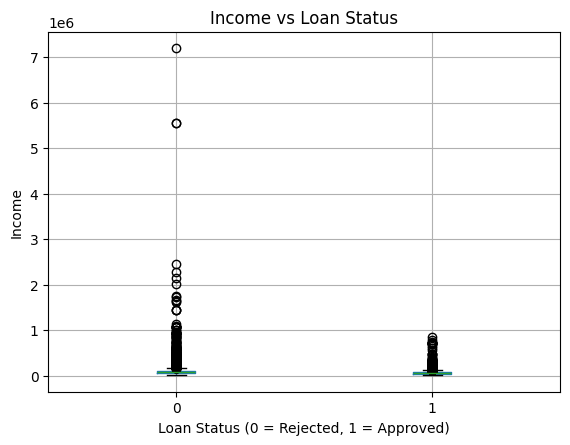

In [7]:
loan.boxplot(column='person_income', by='loan_status')
plt.title("Income vs Loan Status")
plt.suptitle("")   # removes automatic subtitle
plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
plt.ylabel("Income")
plt.show()

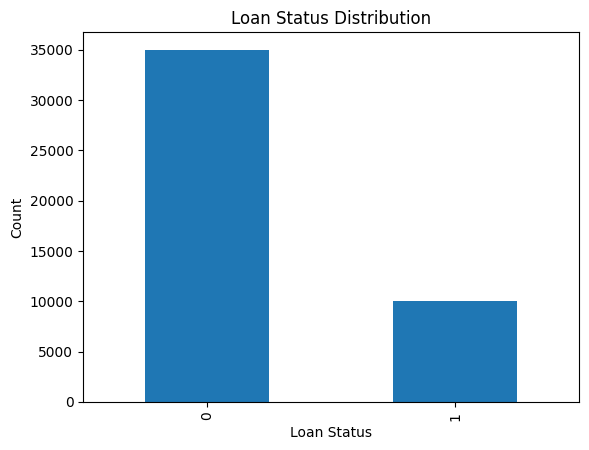

In [8]:
import matplotlib.pyplot as plt

loan['loan_status'].value_counts().plot(kind='bar')
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()


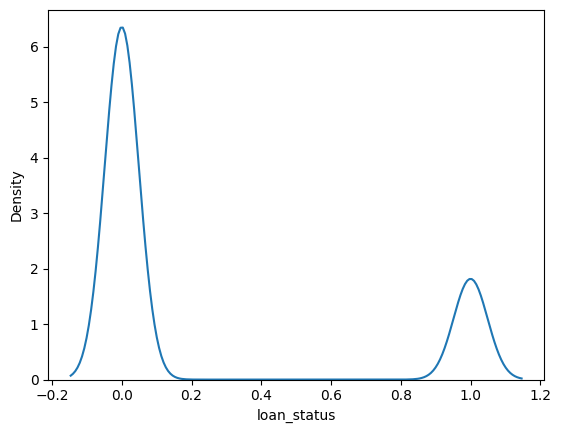

In [10]:
import seaborn as sns

sns.kdeplot(loan["loan_status"])
plt.show()